In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter
import random
seed=42
np.random.seed(seed)
random.seed(seed)



In [3]:
train_df=pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv')
x=train_df.drop('label',axis=1).values
y=train_df['label'].values
x_test=test_df.drop('label',axis=1).values
y_test=test_df['label'].values

In [4]:
x=x/255.0
x_test=x_test/255.0

In [5]:
print(x.shape)

(60000, 784)


In [6]:
x_train, x_val, y_train, y_val=train_test_split(x,y,test_size=0.2,random_state=seed, stratify=y)

In [7]:
print("Training samples: ", x_train.shape[0])
print("Validation samples: ", x_val.shape[0])
print("Test samples: ", x_test.shape[0])

Training samples:  48000
Validation samples:  12000
Test samples:  10000


In [8]:
def class_distribution(labels, name):
    counter=Counter(labels)
    print(f"\n{name} distribution: ")
    for cl, count in sorted(counter.items()):
        print(f"Class {cl} : {count}")
class_distribution(y_train, "Train")
class_distribution(y_val, "Validation")
class_distribution(y_test, "Test")


Train distribution: 
Class 0 : 4800
Class 1 : 4800
Class 2 : 4800
Class 3 : 4800
Class 4 : 4800
Class 5 : 4800
Class 6 : 4800
Class 7 : 4800
Class 8 : 4800
Class 9 : 4800

Validation distribution: 
Class 0 : 1200
Class 1 : 1200
Class 2 : 1200
Class 3 : 1200
Class 4 : 1200
Class 5 : 1200
Class 6 : 1200
Class 7 : 1200
Class 8 : 1200
Class 9 : 1200

Test distribution: 
Class 0 : 1000
Class 1 : 1000
Class 2 : 1000
Class 3 : 1000
Class 4 : 1000
Class 5 : 1000
Class 6 : 1000
Class 7 : 1000
Class 8 : 1000
Class 9 : 1000


<function matplotlib.pyplot.show(close=None, block=None)>

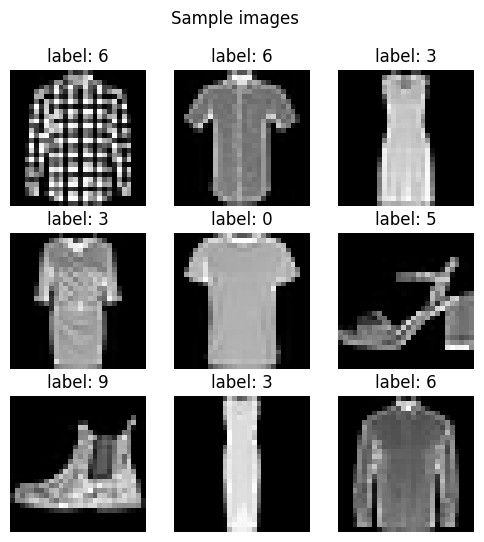

In [9]:
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='grey')
    plt.title(f"label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample images")
plt.show

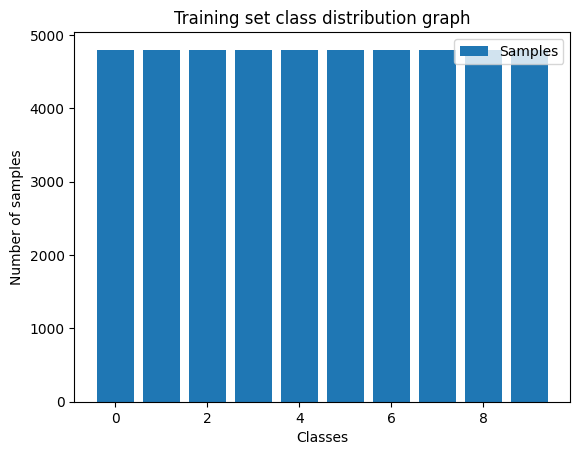

In [10]:
def plot_distribution(labels, title):
    counter=Counter(labels)
    classes=list(counter.keys())
    counts=list(counter.values())
    plt.figure()
    plt.bar(classes, counts)
    plt.xlabel("Classes")
    plt.ylabel("Number of samples")
    plt.title(title)
    plt.legend(["Samples"])
    plt.show()
plot_distribution(y_train, "Training set class distribution graph")

**PART 1**

In [11]:
input_size=784
hidden_size=64
output_size=10
lr=0.01
w1=np.random.randn(input_size,hidden_size)*0.01
b1=np.zeros((1,hidden_size))
w2=np.random.randn(hidden_size,output_size)*0.01
b2=np.zeros((1,output_size))


In [12]:
def relu(x):
    return np.maximum(0,x)
def relu_deriv(x):
    return (x>0).astype(float)
def softmax(x):
    exp=np.exp(x-np.max(x,axis=1, keepdims=True))
    return exp/np.sum(exp,axis=1,keepdims=True)

In [13]:
def forward(x):
    z1=x@w1+b1
    a1=relu(z1)
    z2=a1@w2+b2
    a2=softmax(z2)
    return z1, a1,z2,a2
    

In [14]:
def compute_loss(y_true, y_pred):
    n=y_true.shape[0]
    log_like=-np.log(y_pred[range(n),y_true]+1e-9)
    return np.mean(log_like)

In [15]:
def backward(x, y, z1, a1, a2):
    n = x.shape[0]
    y_onehot = np.zeros_like(a2)
    y_onehot[np.arange(n), y] = 1
    dz2 = (a2 - y_onehot) / n
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)
    da1 = dz2 @ w2.T
    dz1 = da1 * relu_deriv(z1)
    dW1 = x.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2

In [16]:
def update(dW1, db1, dW2, db2):
    global w1, b1, w2, b2
    w1 -= lr * dW1
    b1 -= lr * db1
    w2 -= lr * dW2
    b2 -= lr * db2

In [17]:
X_sub = x_train[:5000]
y_sub = y_train[:5000]
losses = []
for epoch in range(20):
    z1, a1, z2, a2 = forward(X_sub)
    loss = compute_loss(y_sub, a2)
    losses.append(loss)
    dW1, db1, dW2, db2 = backward(X_sub, y_sub, z1, a1, a2)
    update(dW1, db1, dW2, db2)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

Epoch 1, Loss: 2.3044
Epoch 2, Loss: 2.3043
Epoch 3, Loss: 2.3041
Epoch 4, Loss: 2.3039
Epoch 5, Loss: 2.3038
Epoch 6, Loss: 2.3036
Epoch 7, Loss: 2.3035
Epoch 8, Loss: 2.3033
Epoch 9, Loss: 2.3031
Epoch 10, Loss: 2.3030
Epoch 11, Loss: 2.3028
Epoch 12, Loss: 2.3026
Epoch 13, Loss: 2.3025
Epoch 14, Loss: 2.3023
Epoch 15, Loss: 2.3022
Epoch 16, Loss: 2.3020
Epoch 17, Loss: 2.3018
Epoch 18, Loss: 2.3017
Epoch 19, Loss: 2.3015
Epoch 20, Loss: 2.3014


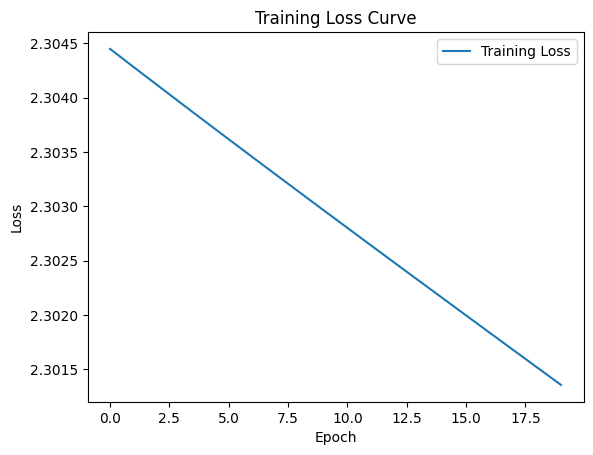

In [18]:
plt.plot(losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()

gradient check with pytorch

In [19]:
import torch
import torch.nn as nn
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(784, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

In [20]:
with torch.no_grad():
    model[0].weight.copy_(torch.tensor(w1.T))
    model[0].bias.copy_(torch.tensor(b1.flatten()))  
    model[2].weight.copy_(torch.tensor(w2.T))
    model[2].bias.copy_(torch.tensor(b2.flatten()))

In [21]:
X_t = torch.tensor(X_sub[:32], dtype=torch.float32)
y_t = torch.tensor(y_sub[:32], dtype=torch.long)
criterion = nn.CrossEntropyLoss()
out = model(X_t)
loss_t = criterion(out, y_t)
loss_t.backward()

In [22]:
z1, a1, z2, a2 = forward(X_sub[:32])
dW1, db1, dW2, db2 = backward(X_sub[:32], y_sub[:32], z1, a1, a2)
torch_dW1 = model[0].weight.grad.numpy().T
torch_dW2 = model[2].weight.grad.numpy().T
print("Max diff W1:", np.max(np.abs(dW1 - torch_dW1)))
print("Max diff W2:", np.max(np.abs(dW2 - torch_dW2)))

Max diff W1: 6.716957363581133e-10
Max diff W2: 4.555182293863869e-09


the max abs difference between numpy and pytorch gradients is in 10^-10 which is extremely small confirming the backpropagation is correct and numerically stable.

**part 2**

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
class MLP(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.act1 = activation
        self.fc2 = nn.Linear(128, 64)
        self.act2 = activation
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        x = self.fc3(x)
        return x

In [24]:
activations = {
    "sigmoid": nn.Sigmoid(),
    "tanh": nn.Tanh(),
    "relu": nn.ReLU(),
    "leaky_relu": nn.LeakyReLU(0.01)
}

In [25]:
def train_model(model, X_train, y_train, X_val, y_val):
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    val_losses = []
    for epoch in range(20):
        model.train()
        out = model(X_train)
        loss = criterion(out, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            val_out = model(X_val)
            val_loss = criterion(val_out, y_val)
            val_losses.append(val_loss.item())

    return val_losses

In [26]:
results = {}
X_t = torch.tensor(x_train[:5000], dtype=torch.float32)
y_t = torch.tensor(y_train[:5000], dtype=torch.long)
X_v = torch.tensor(x_val[:1000], dtype=torch.float32)
y_v = torch.tensor(y_val[:1000], dtype=torch.long)
for name, act in activations.items():
    model = MLP(act)
    losses = train_model(model, X_t, y_t, X_v, y_v)
    results[name] = losses

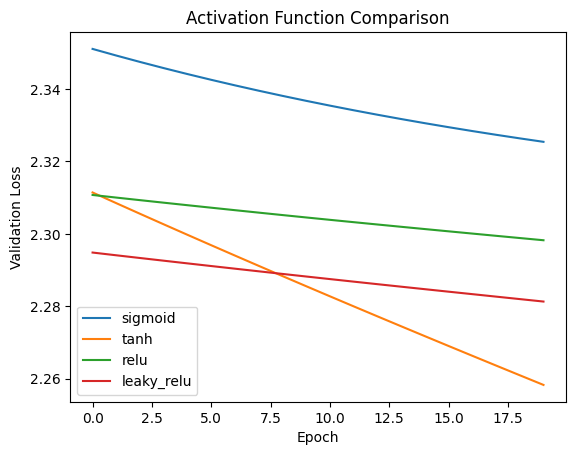

In [27]:
for name, losses in results.items():
    plt.plot(losses, label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Activation Function Comparison")
plt.legend()
plt.show()

Tanh achieved the lowest validation maybe due to its zero centered output, which can improve gradient flow compared to sigmoid. Relu and Leaky Relu also performed well  while sigmoid showed the slowest improvement due to vanishing gradients.

In [28]:
def get_gradients(model, X, y):
    criterion = nn.CrossEntropyLoss()
    out = model(X)
    loss = criterion(out, y)
    model.zero_grad()
    loss.backward()
    grad = model.fc1.weight.grad.abs().mean().item()
    return grad

In [29]:
model_sig = MLP(nn.Sigmoid())
g1_sig = get_gradients(model_sig, X_t, y_t)
train_model(model_sig, X_t, y_t, X_v, y_v)
gfinal_sig = get_gradients(model_sig, X_t, y_t)
model_relu = MLP(nn.ReLU())
g1_relu = get_gradients(model_relu, X_t, y_t)
train_model(model_relu, X_t, y_t, X_v, y_v)
gfinal_relu = get_gradients(model_relu, X_t, y_t)

In [30]:
def dead_relu_percentage(model, X):
    with torch.no_grad():
        h1 = model.act1(model.fc1(X))
        dead = (h1 == 0).all(dim=0) 
        return dead.float().mean().item() * 100

In [31]:
dead_pct = dead_relu_percentage(model_relu, X_v)
print("Dead units %:", dead_pct)

Dead units %: 0.78125


~0.78% of ReLU units were inactive for all inputs, indicating a very small number of dead neurons. This suggests that most neurons remained active and contributed to learning.

**part 3**

In [32]:
torch.manual_seed(42)
model_ce = MLP(nn.ReLU())
optimizer = optim.SGD(model_ce.parameters(), lr=0.01,  momentum=0.9)
criterion_ce = nn.CrossEntropyLoss()

In [33]:
ce_losses = []
for epoch in range(300):
    out = model_ce(X_t)
    loss = criterion_ce(out, y_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    ce_losses.append(loss.item())

In [34]:
with torch.no_grad():
    preds = model_ce(torch.tensor(x_test, dtype=torch.float32))
    predicted = preds.argmax(dim=1).numpy()
acc_ce = (predicted == y_test).mean()
print("CE Accuracy:", acc_ce)

CE Accuracy: 0.8067


In [35]:
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]
y_t_oh = torch.tensor(one_hot(y_train[:5000]), dtype=torch.float32)

In [36]:
torch.manual_seed(42)
model_mse = MLP(nn.ReLU())
optimizer = optim.SGD(model_mse.parameters(), lr=0.01,  momentum=0.9)
criterion_mse = nn.MSELoss()
mse_losses = []
for epoch in range(300):
    out = model_mse(X_t)
    probs = torch.softmax(out, dim=1)  
    loss = criterion_mse(probs, y_t_oh)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    mse_losses.append(loss.item())

In [37]:
with torch.no_grad():
    preds = model_mse(torch.tensor(x_test, dtype=torch.float32))
    predicted = preds.argmax(dim=1).numpy()
acc_mse = (predicted == y_test).mean()
print("MSE Accuracy:", acc_mse)

MSE Accuracy: 0.1975


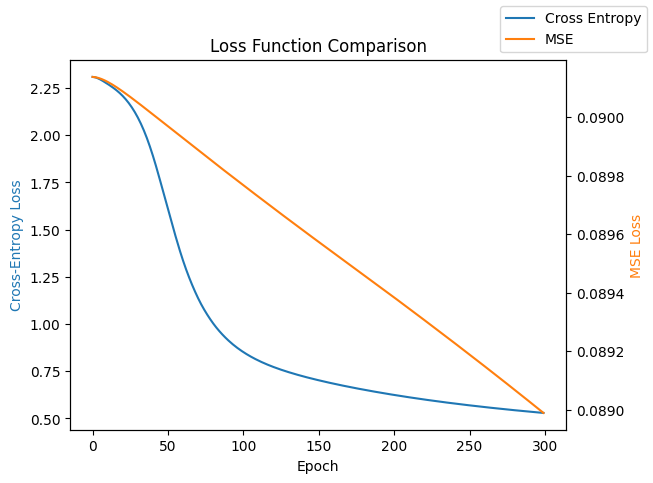

In [38]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(ce_losses, color="tab:blue", label="Cross Entropy")
ax2.plot(mse_losses, color="tab:orange", label="MSE")
ax1.set_ylabel("Cross-Entropy Loss", color="tab:blue")
ax2.set_ylabel("MSE Loss", color="tab:orange")
ax1.set_xlabel("Epoch")
plt.title("Loss Function Comparison")
fig.legend(loc="upper right")
plt.show()

With softmax + cross-entropy, the gradient at the output layer simplifies to (prediction − target), giving a large, constant scale error signal even when the model is confidently wrong; with MSE on softmax outputs, that same error gets multiplied by the softmax derivative, which is near zero when a unit is saturated (confidently wrong or right), so wrong but confident predictions get almost no gradient and learning stalls. 

In [39]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
data = fetch_california_housing()
X_reg = data.data
y_reg = data.target
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
scaler_X = StandardScaler()
X_train_r = scaler_X.fit_transform(X_train_r)
X_test_r = scaler_X.transform(X_test_r)
scaler_y = StandardScaler()
y_train_r = scaler_y.fit_transform(y_train_r.reshape(-1, 1))
y_test_r = scaler_y.transform(y_test_r.reshape(-1, 1))


In [40]:
model_reg = nn.Sequential(
    nn.Linear(X_train_r.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)
optimizer = optim.SGD(model_reg.parameters(), lr=0.01)
criterion = nn.MSELoss()
Xtr = torch.tensor(X_train_r, dtype=torch.float32)
ytr = torch.tensor(y_train_r, dtype=torch.float32)  # already (N,1) shape

for epoch in range(50):
    out = model_reg(Xtr)
    loss = criterion(out, ytr)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
Xte = torch.tensor(X_test_r, dtype=torch.float32)
with torch.no_grad():
    preds_scaled = model_reg(Xte).numpy()
preds = scaler_y.inverse_transform(preds_scaled)
y_test_real = scaler_y.inverse_transform(y_test_r)


In [41]:

mse = mean_squared_error(y_test_real, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_real, preds)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 0.8264073609917901
RMSE: 0.909069502838914
MAE: 0.7101208970611732


**part 4**

In [42]:
import time

def get_optimizer(name, model, lr):
    if name == "sgd":
        return optim.SGD(model.parameters(), lr=lr)
    if name == "sgd_momentum":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    if name == "rmsprop":
        return optim.RMSprop(model.parameters(), lr=lr)
    if name == "adam":
        return optim.Adam(model.parameters(), lr=lr)

In [43]:
def train_optimizer(name, lr, epochs=500):
    torch.manual_seed(42)
    model = MLP(nn.ReLU())
    optimizer = get_optimizer(name, model, lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    epoch_85 = None
    start = time.time()

    for epoch in range(epochs):
        out = model(X_t)
        loss = criterion(out, y_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        with torch.no_grad():
            val_out = model(X_v)
            val_acc = (val_out.argmax(dim=1) == y_v).float().mean().item()
        if epoch_85 is None and val_acc >= 0.85:
            epoch_85 = epoch + 1

    elapsed = time.time() - start
    return train_losses, epoch_85, elapsed, val_acc

run 1: same learning rate for all optimisers

In [44]:
optimizer_names = ["sgd", "sgd_momentum", "rmsprop", "adam"]
run1 = {}

for name in optimizer_names:
    losses, ep85, t, vacc = train_optimizer(name, lr=0.01)
    run1[name] = {"losses": losses, "epoch_85": ep85, "time": t, "val_acc": vacc}
    print(name, "-> epoch_85:", ep85, ", time:", round(t, 2), "s, final val acc:", round(vacc, 4))

sgd -> epoch_85: None , time: 14.55 s, final val acc: 0.614
sgd_momentum -> epoch_85: None , time: 14.46 s, final val acc: 0.815
rmsprop -> epoch_85: None , time: 14.64 s, final val acc: 0.81
adam -> epoch_85: None , time: 14.94 s, final val acc: 0.825


run 2: learning rate search per optimiser

In [45]:
lr_grid = {
    "sgd": [0.05, 0.1, 0.3],
    "sgd_momentum": [0.02, 0.05, 0.1],
    "rmsprop": [0.001, 0.005, 0.01],
    "adam": [0.001, 0.005, 0.01]
}

search_results = {}
for name, lrs in lr_grid.items():
    for lr in lrs:
        losses, ep85, t, vacc = train_optimizer(name, lr=lr)
        search_results[(name, lr)] = vacc
        print(name, lr, "-> val acc:", round(vacc, 4), ", epoch_85:", ep85)

sgd 0.05 -> val acc: 0.776 , epoch_85: None
sgd 0.1 -> val acc: 0.777 , epoch_85: None
sgd 0.3 -> val acc: 0.841 , epoch_85: None
sgd_momentum 0.02 -> val acc: 0.828 , epoch_85: None
sgd_momentum 0.05 -> val acc: 0.826 , epoch_85: None
sgd_momentum 0.1 -> val acc: 0.828 , epoch_85: None
rmsprop 0.001 -> val acc: 0.827 , epoch_85: None
rmsprop 0.005 -> val acc: 0.837 , epoch_85: None
rmsprop 0.01 -> val acc: 0.81 , epoch_85: None
adam 0.001 -> val acc: 0.821 , epoch_85: None
adam 0.005 -> val acc: 0.829 , epoch_85: None
adam 0.01 -> val acc: 0.825 , epoch_85: None


final tuned run — best lr per optimiser, extended epochs

In [46]:
best_lr = {
    "sgd": 0.3,
    "sgd_momentum": 0.1,
    "rmsprop": 0.005,
    "adam": 0.005
}

final_results = {}
for name, lr in best_lr.items():
    losses, ep85, t, vacc = train_optimizer(name, lr=lr, epochs=1500)
    final_results[name] = {"lr": lr, "losses": losses, "epoch_85": ep85, "time": t, "val_acc": vacc}
    print(name, "-> lr:", lr, ", epoch_85:", ep85, ", time:", round(t, 2), "s, final val acc:", round(vacc, 4))

sgd -> lr: 0.3 , epoch_85: None , time: 45.85 s, final val acc: 0.817
sgd_momentum -> lr: 0.1 , epoch_85: None , time: 44.04 s, final val acc: 0.812
rmsprop -> lr: 0.005 , epoch_85: None , time: 44.08 s, final val acc: 0.82
adam -> lr: 0.005 , epoch_85: None , time: 45.29 s, final val acc: 0.825


none of the optimisers reached 85% validation accuracy within 1500 full-batch epochs on the 5000-sample subset, likely due to the small training set and full-batch updates limiting how far the model can generalise. reporting final validation accuracy instead as the comparison metric.

In [47]:
import pandas as pd

table = pd.DataFrame({
    "Optimiser": ["SGD", "SGD + momentum", "RMSProp", "Adam"],
    "Learning rate": [final_results["sgd"]["lr"], final_results["sgd_momentum"]["lr"],
                       final_results["rmsprop"]["lr"], final_results["adam"]["lr"]],
    "Epochs to 85% val acc": ["not reached", "not reached", "not reached", "not reached"],
    "Wall-clock time (s)": [round(final_results["sgd"]["time"], 2), round(final_results["sgd_momentum"]["time"], 2),
                             round(final_results["rmsprop"]["time"], 2), round(final_results["adam"]["time"], 2)],
    "Final val accuracy": [round(final_results["sgd"]["val_acc"], 4), round(final_results["sgd_momentum"]["val_acc"], 4),
                            round(final_results["rmsprop"]["val_acc"], 4), round(final_results["adam"]["val_acc"], 4)]
})
table

,Optimiser,Learning rate,Epochs to 85% val acc,Wall-clock time (s),Final val accuracy
0,SGD,0.300,not reached,45.85,0.817
1,SGD + momentum,0.100,not reached,44.04,0.812
2,RMSProp,0.005,not reached,44.08,0.820
3,Adam,0.005,not reached,45.29,0.825


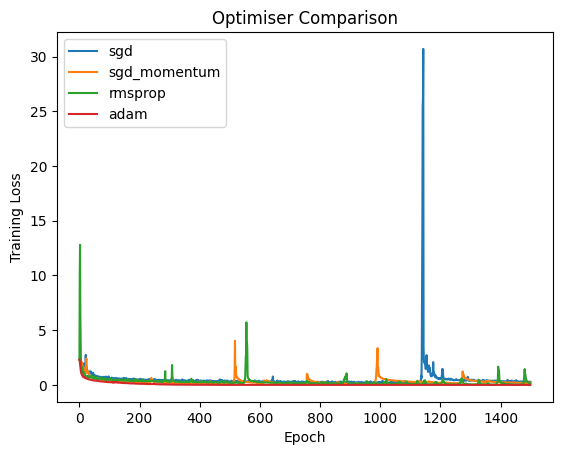

In [48]:
for name in best_lr.keys():
    plt.plot(final_results[name]["losses"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Optimiser Comparison")
plt.legend()
plt.show()

Adam gave the best final validation accuracy (82.5%) and the most stable training curve, with almost no loss spikes compared to SGD and RMSProp which both showed sharp instability at their tuned learning rates. SGD required the largest learning rate (0.3) to be competitive at all, and even then produced the biggest spike in training loss, suggesting it is far more sensitive to learning rate choice than the adaptive optimisers.

**part 5**

In [49]:
X_small = torch.tensor(x_train[:2000], dtype=torch.float32)
y_small = torch.tensor(y_train[:2000], dtype=torch.long)

In [50]:
class BigMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)
        self.fc5 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.fc5(x)
        return x

training the oversized model on the reduced training set to force overfitting

In [51]:
torch.manual_seed(42)
model_big = BigMLP()
optimizer = optim.Adam(model_big.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(300):
    model_big.train()
    out = model_big(X_small)
    loss = criterion(out, y_small)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_acc = (out.argmax(dim=1) == y_small).float().mean().item()
    train_losses.append(loss.item())
    train_accs.append(train_acc)

    model_big.eval()
    with torch.no_grad():
        val_out = model_big(X_v)
        val_loss = criterion(val_out, y_v)
        val_acc = (val_out.argmax(dim=1) == y_v).float().mean().item()
    val_losses.append(val_loss.item())
    val_accs.append(val_acc)

print("final train acc:", train_accs[-1])
print("final val acc:", val_accs[-1])

final train acc: 1.0
final val acc: 0.8080000281333923


plotting train vs validation loss to find the point of overfitting

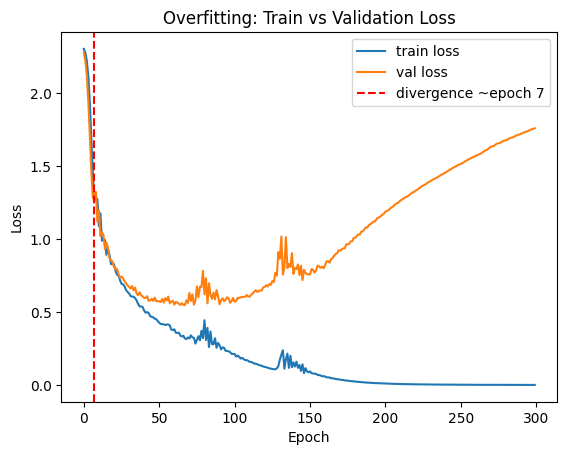

generalisation gap (train acc - val acc): 0.19199997186660767


In [52]:
gap_epoch = None
for i in range(1, len(val_losses)):
    if val_losses[i] > val_losses[i-1] and train_losses[i] < train_losses[i-1]:
        gap_epoch = i
        break

plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
if gap_epoch:
    plt.axvline(gap_epoch, color="red", linestyle="--", label=f"divergence ~epoch {gap_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Overfitting: Train vs Validation Loss")
plt.legend()
plt.show()

print("generalisation gap (train acc - val acc):", train_accs[-1] - val_accs[-1])

In [53]:
val_min_epoch = val_losses.index(min(val_losses))
print("val loss reaches its minimum at epoch:", val_min_epoch, ", value:", min(val_losses))

val loss reaches its minimum at epoch: 67 , value: 0.5464841723442078


this model shows high variance rather than high bias. train accuracy reaches 100% while validation accuracy stays at 80.8%, a generalisation gap of about 19 percentage points. validation loss reaches its minimum around epoch 67 and rises steadily afterward even as training loss keeps falling to near zero, meaning the model is memorising the 2000 training samples rather than learning patterns that generalise. high bias would instead show both train and validation accuracy staying low together, which is not the case here.

**part 6**

In [54]:
class RegMLP(nn.Module):
    def __init__(self, dropout=0.0, use_bn=False):
        super().__init__()
        self.use_bn = use_bn
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)
        self.fc5 = nn.Linear(512, 10)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        if use_bn:
            self.bn1 = nn.BatchNorm1d(512)
            self.bn2 = nn.BatchNorm1d(512)
            self.bn3 = nn.BatchNorm1d(512)
            self.bn4 = nn.BatchNorm1d(512)

    def forward(self, x):
        x = self.fc1(x)
        if self.use_bn: x = self.bn1(x)
        x = self.drop(self.relu(x))
        x = self.fc2(x)
        if self.use_bn: x = self.bn2(x)
        x = self.drop(self.relu(x))
        x = self.fc3(x)
        if self.use_bn: x = self.bn3(x)
        x = self.drop(self.relu(x))
        x = self.fc4(x)
        if self.use_bn: x = self.bn4(x)
        x = self.drop(self.relu(x))
        x = self.fc5(x)
        return x

In [55]:
def train_reg(model, X, y, X_val, y_val, epochs=300, lr=0.001, weight_decay=0.0, l1_lambda=0.0, patience=None):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    best_val_loss = float("inf")
    wait = 0
    stop_epoch = epochs

    for epoch in range(epochs):
        model.train()
        out = model(X)
        loss = criterion(out, y)
        if l1_lambda > 0:
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_out = model(X_val)
            val_loss = criterion(val_out, y_val)

        if patience is not None:
            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    stop_epoch = epoch + 1
                    break

    model.eval()
    with torch.no_grad():
        train_acc = (model(X).argmax(dim=1) == y).float().mean().item()
        val_acc = (model(X_val).argmax(dim=1) == y_val).float().mean().item()
    return train_acc, val_acc, stop_epoch

baseline (no regularisation) using the shared training function, for comparison against every method below

In [56]:
torch.manual_seed(42)
model_base = RegMLP(dropout=0.0, use_bn=False)
train_acc_base, val_acc_base, _ = train_reg(model_base, X_small, y_small, X_v, y_v, epochs=300, lr=0.001)
print("baseline -> train acc:", train_acc_base, ", val acc:", val_acc_base, ", gap:", train_acc_base - val_acc_base)

baseline -> train acc: 1.0 , val acc: 0.8080000281333923 , gap: 0.19199997186660767


l2 weight decay at three values of lambda

In [57]:
l2_results = {}
for wd in [0.0001, 0.001, 0.01]:
    torch.manual_seed(42)
    model_l2 = RegMLP(dropout=0.0, use_bn=False)
    train_acc, val_acc, _ = train_reg(model_l2, X_small, y_small, X_v, y_v, epochs=300, lr=0.001, weight_decay=wd)
    l2_results[wd] = (train_acc, val_acc)
    print("weight_decay:", wd, "-> train acc:", train_acc, ", val acc:", val_acc, ", gap:", train_acc - val_acc)

weight_decay: 0.0001 -> train acc: 1.0 , val acc: 0.8050000071525574 , gap: 0.19499999284744263
weight_decay: 0.001 -> train acc: 1.0 , val acc: 0.8069999814033508 , gap: 0.19300001859664917
weight_decay: 0.01 -> train acc: 0.9300000071525574 , val acc: 0.8040000200271606 , gap: 0.12599998712539673


l1 penalty, plus checking how many weights get pushed near zero

In [58]:
torch.manual_seed(42)
model_l1 = RegMLP(dropout=0.0, use_bn=False)
train_acc_l1, val_acc_l1, _ = train_reg(model_l1, X_small, y_small, X_v, y_v, epochs=300, lr=0.001, l1_lambda=0.00001)
print("l1 -> train acc:", train_acc_l1, ", val acc:", val_acc_l1, ", gap:", train_acc_l1 - val_acc_l1)

all_weights = torch.cat([p.flatten() for p in model_l1.parameters()])
small_pct = (all_weights.abs() < 1e-3).float().mean().item() * 100
print("percentage of weights below 1e-3:", small_pct)

l1 -> train acc: 1.0 , val acc: 0.8100000023841858 , gap: 0.1899999976158142
percentage of weights below 1e-3: 26.106134057044983


In [60]:
torch.manual_seed(42)
model_l1b = RegMLP(dropout=0.0, use_bn=False)
train_acc_l1b, val_acc_l1b, _ = train_reg(model_l1b, X_small, y_small, X_v, y_v, epochs=300, lr=0.001, l1_lambda=0.0001)
print("l1 (stronger) -> train acc:", train_acc_l1b, ", val acc:", val_acc_l1b, ", gap:", train_acc_l1b - val_acc_l1b)

all_weights_b = torch.cat([p.flatten() for p in model_l1b.parameters()])
small_pct_b = (all_weights_b.abs() < 1e-3).float().mean().item() * 100
print("percentage of weights below 1e-3:", small_pct_b)

l1 (stronger) -> train acc: 0.921999990940094 , val acc: 0.8100000023841858 , gap: 0.1119999885559082
percentage of weights below 1e-3: 77.84568667411804


dropout at three rates

In [61]:
dropout_results = {}
for p in [0.2, 0.5, 0.7]:
    torch.manual_seed(42)
    model_do = RegMLP(dropout=p, use_bn=False)
    train_acc, val_acc, _ = train_reg(model_do, X_small, y_small, X_v, y_v, epochs=300, lr=0.001)
    dropout_results[p] = (train_acc, val_acc)
    print("dropout:", p, "-> train acc:", train_acc, ", val acc:", val_acc, ", gap:", train_acc - val_acc)

dropout: 0.2 -> train acc: 1.0 , val acc: 0.8270000219345093 , gap: 0.17299997806549072
dropout: 0.5 -> train acc: 0.9990000128746033 , val acc: 0.828000009059906 , gap: 0.17100000381469727
dropout: 0.7 -> train acc: 0.9620000123977661 , val acc: 0.8240000009536743 , gap: 0.1380000114440918


batch normalisation

In [62]:
torch.manual_seed(42)
model_bn = RegMLP(dropout=0.0, use_bn=True)
train_acc_bn, val_acc_bn, _ = train_reg(model_bn, X_small, y_small, X_v, y_v, epochs=300, lr=0.001)
print("batchnorm -> train acc:", train_acc_bn, ", val acc:", val_acc_bn, ", gap:", train_acc_bn - val_acc_bn)

batchnorm -> train acc: 1.0 , val acc: 0.828000009059906 , gap: 0.171999990940094


early stopping with patience of 15 epochs

In [63]:
torch.manual_seed(42)
model_es = RegMLP(dropout=0.0, use_bn=False)
train_acc_es, val_acc_es, stop_epoch_es = train_reg(model_es, X_small, y_small, X_v, y_v, epochs=300, lr=0.001, patience=15)
print("early stopping -> train acc:", train_acc_es, ", val acc:", val_acc_es, ", gap:", train_acc_es - val_acc_es, ", stopped at epoch:", stop_epoch_es)

early stopping -> train acc: 0.9045000076293945 , val acc: 0.8130000233650208 , gap: 0.09149998426437378 , stopped at epoch: 83


data augmentation using random horizontal flip and small rotation

In [64]:
import random

def augment_batch(X):
    imgs = X.view(-1, 28, 28)
    out = torch.zeros_like(imgs)
    for i in range(imgs.shape[0]):
        img = imgs[i]
        if random.random() < 0.5:
            img = torch.flip(img, dims=[1])
        angle = random.uniform(-10, 10)
        img_np = img.numpy()
        from scipy.ndimage import rotate
        img_np = rotate(img_np, angle, reshape=False, mode="nearest")
        out[i] = torch.tensor(img_np)
    return out.view(-1, 784)

X_aug = augment_batch(X_small)
X_aug_combined = torch.cat([X_small, X_aug], dim=0)
y_aug_combined = torch.cat([y_small, y_small], dim=0)
print("augmented training set size:", X_aug_combined.shape[0])

augmented training set size: 4000


In [65]:
torch.manual_seed(42)
model_aug = RegMLP(dropout=0.0, use_bn=False)
train_acc_aug, val_acc_aug, _ = train_reg(model_aug, X_aug_combined, y_aug_combined, X_v, y_v, epochs=300, lr=0.001)
print("augmentation -> train acc:", train_acc_aug, ", val acc:", val_acc_aug, ", gap:", train_acc_aug - val_acc_aug)

augmentation -> train acc: 1.0 , val acc: 0.8140000104904175 , gap: 0.18599998950958252


retraining with more original training data — 10000 and 20000 samples

In [66]:
more_data_results = {}
for n in [10000, 20000]:
    X_more = torch.tensor(x_train[:n], dtype=torch.float32)
    y_more = torch.tensor(y_train[:n], dtype=torch.long)
    torch.manual_seed(42)
    model_more = RegMLP(dropout=0.0, use_bn=False)
    train_acc, val_acc, _ = train_reg(model_more, X_more, y_more, X_v, y_v, epochs=300, lr=0.001)
    more_data_results[n] = (train_acc, val_acc)
    print("n:", n, "-> train acc:", train_acc, ", val acc:", val_acc, ", gap:", train_acc - val_acc)

n: 10000 -> train acc: 0.907800018787384 , val acc: 0.8220000267028809 , gap: 0.08579999208450317
n: 20000 -> train acc: 0.9405999779701233 , val acc: 0.871999979019165 , gap: 0.06859999895095825


full regularisation results table

In [67]:
import pandas as pd

results_table = pd.DataFrame({
    "Method": ["Baseline (no regularisation)", "L2 weight decay", "L1 penalty", "Dropout",
               "Batch normalisation", "Early stopping", "Data augmentation", "More training data"],
    "Setting": ["-", "lambda=0.01", "lambda=0.0001", "rate=0.7", "-", "patience=15, stopped epoch 83",
                "flip + rotation, 4000 samples", "20000 samples"],
    "Train accuracy": [train_acc_base, l2_results[0.01][0], train_acc_l1b, dropout_results[0.7][0],
                        train_acc_bn, train_acc_es, train_acc_aug, more_data_results[20000][0]],
    "Validation accuracy": [val_acc_base, l2_results[0.01][1], val_acc_l1b, dropout_results[0.7][1],
                             val_acc_bn, val_acc_es, val_acc_aug, more_data_results[20000][1]],
})
results_table["Gap"] = results_table["Train accuracy"] - results_table["Validation accuracy"]
results_table

,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline (no regularisation),-,1.0000,0.808,0.1920
1,L2 weight decay,lambda=0.01,0.9300,0.804,0.1260
2,L1 penalty,lambda=0.0001,0.9220,0.810,0.1120
3,Dropout,rate=0.7,0.9620,0.824,0.1380
4,Batch normalisation,-,1.0000,0.828,0.1720
5,Early stopping,"patience=15, stopped epoch 83",0.9045,0.813,0.0915
6,Data augmentation,"flip + rotation, 4000 samples",1.0000,0.814,0.1860
7,More training data,20000 samples,0.9406,0.872,0.0686


plotting generalisation gap against regularisation strength for l2 and dropout

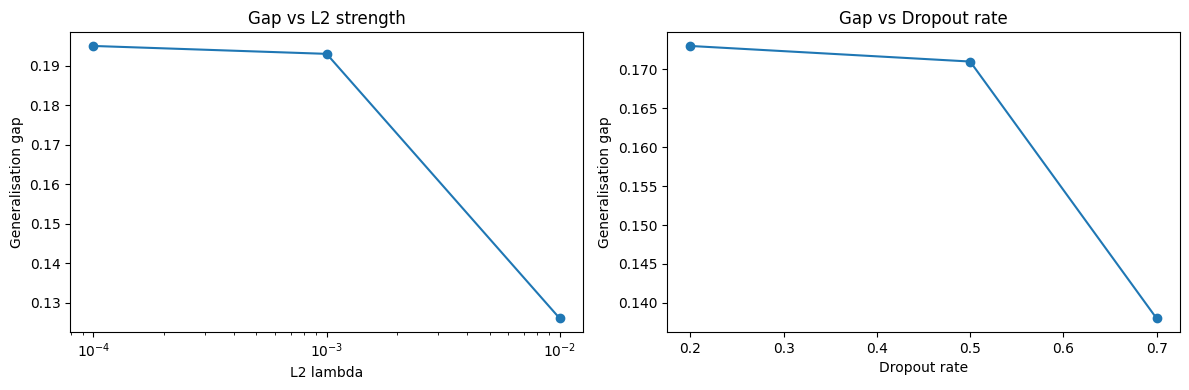

In [68]:
l2_lambdas = list(l2_results.keys())
l2_gaps = [l2_results[wd][0] - l2_results[wd][1] for wd in l2_lambdas]

dropout_rates = list(dropout_results.keys())
dropout_gaps = [dropout_results[p][0] - dropout_results[p][1] for p in dropout_rates]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(l2_lambdas, l2_gaps, marker="o")
axes[0].set_xscale("log")
axes[0].set_xlabel("L2 lambda")
axes[0].set_ylabel("Generalisation gap")
axes[0].set_title("Gap vs L2 strength")

axes[1].plot(dropout_rates, dropout_gaps, marker="o")
axes[1].set_xlabel("Dropout rate")
axes[1].set_ylabel("Generalisation gap")
axes[1].set_title("Gap vs Dropout rate")

plt.tight_layout()
plt.show()

In [69]:
torch.manual_seed(42)
model_l2_extreme = RegMLP(dropout=0.0, use_bn=False)
train_acc_l2e, val_acc_l2e, _ = train_reg(model_l2_extreme, X_small, y_small, X_v, y_v, epochs=300, lr=0.001, weight_decay=0.1)
print("l2 extreme (0.1) -> train acc:", train_acc_l2e, ", val acc:", val_acc_l2e, ", gap:", train_acc_l2e - val_acc_l2e)

torch.manual_seed(42)
model_do_extreme = RegMLP(dropout=0.9, use_bn=False)
train_acc_doe, val_acc_doe, _ = train_reg(model_do_extreme, X_small, y_small, X_v, y_v, epochs=300, lr=0.001)
print("dropout extreme (0.9) -> train acc:", train_acc_doe, ", val acc:", val_acc_doe, ", gap:", train_acc_doe - val_acc_doe)

l2 extreme (0.1) -> train acc: 0.10849999636411667 , val acc: 0.09099999815225601 , gap: 0.017499998211860657
dropout extreme (0.9) -> train acc: 0.13099999725818634 , val acc: 0.11999999731779099 , gap: 0.010999999940395355


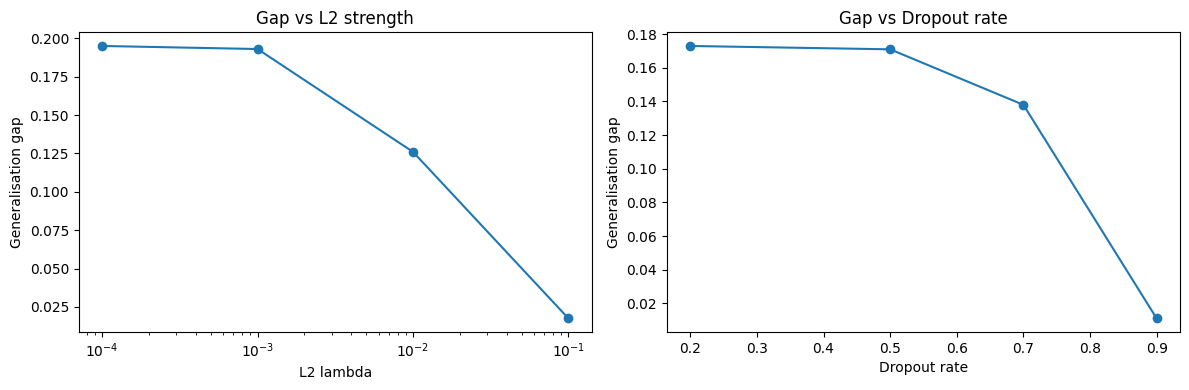

In [70]:
l2_results[0.1] = (train_acc_l2e, val_acc_l2e)
dropout_results[0.9] = (train_acc_doe, val_acc_doe)

l2_lambdas = sorted(l2_results.keys())
l2_gaps = [l2_results[wd][0] - l2_results[wd][1] for wd in l2_lambdas]

dropout_rates = sorted(dropout_results.keys())
dropout_gaps = [dropout_results[p][0] - dropout_results[p][1] for p in dropout_rates]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(l2_lambdas, l2_gaps, marker="o")
axes[0].set_xscale("log")
axes[0].set_xlabel("L2 lambda")
axes[0].set_ylabel("Generalisation gap")
axes[0].set_title("Gap vs L2 strength")

axes[1].plot(dropout_rates, dropout_gaps, marker="o")
axes[1].set_xlabel("Dropout rate")
axes[1].set_ylabel("Generalisation gap")
axes[1].set_title("Gap vs Dropout rate")

plt.tight_layout()
plt.show()

early stopping gave the largest reduction in the generalisation gap for the smallest cost in training accuracy, cutting the gap from 19.2% to 9.15% while keeping validation accuracy essentially unchanged (81.3% vs the baseline's 80.8%) and only losing about 10 points of train accuracy. more training data produced the lowest gap among methods that still generalise well (6.9%) with the highest validation accuracy (87.2%), but this is not a regularisation technique in the same sense, it simply gives the model less to memorise relative to its capacity.

the gap vs strength plots for l2 and dropout show the gap shrinking sharply at the extreme settings tested (l2 lambda=0.1, dropout=0.9), but this is over-regularisation, not improvement: at l2=0.1 both train and validation accuracy collapsed to about 9-11%, and at dropout=0.9 both collapsed to about 12-13%, both close to the 10% chance level for a 10-class problem. the gap looks small only because the model can no longer learn the training data either. the moderate settings (l2=0.01, dropout=0.7) are the useful operating points, cutting the gap to 12.6% and 13.8% respectively while keeping validation accuracy near baseline.

**part 7**

In [71]:
import numpy as np
from sklearn.model_selection import KFold

random.seed(42)
np.random.seed(42)

def sample_config():
    lr = 10 ** random.uniform(-4, -2)
    hidden = random.choice([64, 128, 256, 512])
    dropout = random.uniform(0.1, 0.6)
    return {"lr": lr, "hidden": hidden, "dropout": dropout}

configs = [sample_config() for _ in range(12)]
for c in configs:
    print(c)

{'lr': 0.0019004375238737116, 'hidden': 64, 'dropout': 0.4707752498799165}
{'lr': 0.00030887567507992714, 'hidden': 128, 'dropout': 0.4682356070820062}
{'lr': 0.0022563110735889097, 'hidden': 64, 'dropout': 0.3952462562245198}
{'lr': 0.00011576182342480786, 'hidden': 64, 'dropout': 0.2093189874018017}
{'lr': 0.0010249686360134878, 'hidden': 64, 'dropout': 0.38062253146930647}
{'lr': 0.0027042025989441032, 'hidden': 512, 'dropout': 0.21022031102034835}
{'lr': 0.0015084515574125298, 'hidden': 64, 'dropout': 0.4794036835648836}
{'lr': 0.00020860207915065766, 'hidden': 512, 'dropout': 0.2701252582589959}
{'lr': 0.00020462514474407193, 'hidden': 256, 'dropout': 0.15110513825992436}
{'lr': 0.0005752473163560671, 'hidden': 256, 'dropout': 0.5237471831737299}
{'lr': 0.0016123230498862884, 'hidden': 64, 'dropout': 0.464865893346909}
{'lr': 0.0011815610957838962, 'hidden': 512, 'dropout': 0.1394000990392291}


In [72]:
class TunableMLP(nn.Module):
    def __init__(self, hidden, dropout):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, 10)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.drop(self.relu(self.fc1(x)))
        x = self.drop(self.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

5-fold cross-validation for each sampled configuration, scored on the training data only

In [73]:
X_cv = torch.tensor(x_train[:5000], dtype=torch.float32)
y_cv = torch.tensor(y_train[:5000], dtype=torch.long)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for i, cfg in enumerate(configs):
    fold_accs = []
    for train_idx, val_idx in kf.split(X_cv):
        torch.manual_seed(42)
        model = TunableMLP(cfg["hidden"], cfg["dropout"])
        optimizer = optim.Adam(model.parameters(), lr=cfg["lr"])
        criterion = nn.CrossEntropyLoss()

        Xf_train, yf_train = X_cv[train_idx], y_cv[train_idx]
        Xf_val, yf_val = X_cv[val_idx], y_cv[val_idx]

        for epoch in range(60):
            model.train()
            out = model(Xf_train)
            loss = criterion(out, yf_train)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            fold_acc = (model(Xf_val).argmax(dim=1) == yf_val).float().mean().item()
        fold_accs.append(fold_acc)

    mean_acc = np.mean(fold_accs)
    std_acc = np.std(fold_accs)
    cv_results.append({"config": cfg, "mean_acc": mean_acc, "std_acc": std_acc})
    print(f"config {i}: mean={mean_acc:.4f}, std={std_acc:.4f}, {cfg}")

config 0: mean=0.7376, std=0.0130, {'lr': 0.0019004375238737116, 'hidden': 64, 'dropout': 0.4707752498799165}
config 1: mean=0.6662, std=0.0163, {'lr': 0.00030887567507992714, 'hidden': 128, 'dropout': 0.4682356070820062}
config 2: mean=0.7692, std=0.0106, {'lr': 0.0022563110735889097, 'hidden': 64, 'dropout': 0.3952462562245198}
config 3: mean=0.5422, std=0.0199, {'lr': 0.00011576182342480786, 'hidden': 64, 'dropout': 0.2093189874018017}
config 4: mean=0.7094, std=0.0116, {'lr': 0.0010249686360134878, 'hidden': 64, 'dropout': 0.38062253146930647}
config 5: mean=0.8502, std=0.0039, {'lr': 0.0027042025989441032, 'hidden': 512, 'dropout': 0.21022031102034835}
config 6: mean=0.7176, std=0.0074, {'lr': 0.0015084515574125298, 'hidden': 64, 'dropout': 0.4794036835648836}
config 7: mean=0.7666, std=0.0035, {'lr': 0.00020860207915065766, 'hidden': 512, 'dropout': 0.2701252582589959}
config 8: mean=0.7020, std=0.0158, {'lr': 0.00020462514474407193, 'hidden': 256, 'dropout': 0.15110513825992436}

top 5 configurations by mean cross-validation accuracy, and the selected configuration

In [74]:
cv_sorted = sorted(cv_results, key=lambda r: r["mean_acc"], reverse=True)
top5 = cv_sorted[:5]

for i, r in enumerate(top5):
    print(f"rank {i+1}: mean={r['mean_acc']:.4f}, std={r['std_acc']:.4f}, config={r['config']}")

best_config = top5[0]["config"]
print("\nselected configuration:", best_config)

rank 1: mean=0.8502, std=0.0039, config={'lr': 0.0027042025989441032, 'hidden': 512, 'dropout': 0.21022031102034835}
rank 2: mean=0.8410, std=0.0045, config={'lr': 0.0011815610957838962, 'hidden': 512, 'dropout': 0.1394000990392291}
rank 3: mean=0.7714, std=0.0067, config={'lr': 0.0005752473163560671, 'hidden': 256, 'dropout': 0.5237471831737299}
rank 4: mean=0.7692, std=0.0106, config={'lr': 0.0022563110735889097, 'hidden': 64, 'dropout': 0.3952462562245198}
rank 5: mean=0.7666, std=0.0035, config={'lr': 0.00020860207915065766, 'hidden': 512, 'dropout': 0.2701252582589959}

selected configuration: {'lr': 0.0027042025989441032, 'hidden': 512, 'dropout': 0.21022031102034835}


the selected configuration uses hidden width 512, learning rate ≈0.0027, and dropout ≈0.21, with mean cross-validation accuracy of 85.0% and the lowest standard deviation across folds (0.0039) among the top candidates, indicating both the best and most stable performance. the top two configurations both used the largest hidden width tested (512), suggesting model capacity was the limiting factor for the smaller-width configs given this amount of training data.

retraining the selected configuration on the full training set, combined with early stopping from part 6

In [75]:
X_full = torch.tensor(x_train, dtype=torch.float32)
y_full = torch.tensor(y_train, dtype=torch.long)

torch.manual_seed(42)
final_model = TunableMLP(hidden=best_config["hidden"], dropout=best_config["dropout"])
optimizer = optim.Adam(final_model.parameters(), lr=best_config["lr"])
criterion = nn.CrossEntropyLoss()

patience = 15
best_val_loss = float("inf")
wait = 0
stop_epoch = None

for epoch in range(300):
    final_model.train()
    out = final_model(X_full)
    loss = criterion(out, y_full)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    final_model.eval()
    with torch.no_grad():
        val_out = final_model(X_v)
        val_loss = criterion(val_out, y_v)

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            stop_epoch = epoch + 1
            break

print("stopped at epoch:", stop_epoch)

stopped at epoch: 196


final evaluation on the held-out test set — accuracy, macro precision, macro recall, macro f1, and confusion matrix

test accuracy: 0.8943
macro precision: 0.8951711591208822
macro recall: 0.8943
macro f1: 0.8942191377945052


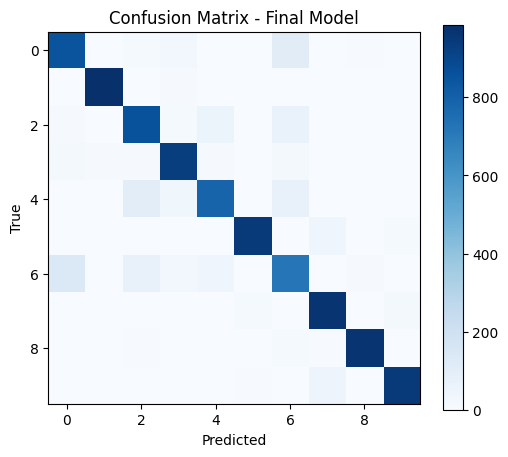

In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X_test_t = torch.tensor(x_test, dtype=torch.float32)

final_model.eval()
with torch.no_grad():
    test_preds = final_model(X_test_t).argmax(dim=1).numpy()

test_acc = accuracy_score(y_test, test_preds)
test_prec = precision_score(y_test, test_preds, average="macro")
test_rec = recall_score(y_test, test_preds, average="macro")
test_f1 = f1_score(y_test, test_preds, average="macro")

print("test accuracy:", test_acc)
print("macro precision:", test_prec)
print("macro recall:", test_rec)
print("macro f1:", test_f1)

cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Final Model")
plt.show()

part 2 did not report a test accuracy (only validation loss and dead-relu percentage), and part 3's classification test accuracy is flagged as unreliable due to a mismatched epoch budget between the ce and mse runs. training a clean part 2-architecture baseline on the full training set here to get a fair, honest number to compare the tuned model against.

In [77]:
torch.manual_seed(42)
baseline_model = MLP(nn.ReLU())
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(200):
    baseline_model.train()
    out = baseline_model(X_full)
    loss = criterion(out, y_full)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

baseline_model.eval()
with torch.no_grad():
    baseline_preds = baseline_model(X_test_t).argmax(dim=1).numpy()
baseline_test_acc = accuracy_score(y_test, baseline_preds)
print("part 2 architecture baseline test accuracy:", baseline_test_acc)

part 2 architecture baseline test accuracy: 0.8678


In [78]:
improvement = (test_acc - baseline_test_acc) * 100
print("part 2 baseline test accuracy:", baseline_test_acc)
print("final tuned model test accuracy:", test_acc)
print("improvement in percentage points:", improvement)

part 2 baseline test accuracy: 0.8678
final tuned model test accuracy: 0.8943
improvement in percentage points: 2.649999999999997


the tuned model (hidden width 512, lr≈0.0027, dropout≈0.21, selected via random search + 5-fold cv, retrained on the full training set with early stopping) achieved 89.43% test accuracy, compared to 86.78% for a plain, untuned part 2-style baseline (784-128-64-10, relu, no regularisation) trained under the same conditions. this is an improvement of about 2.65 percentage points. the gain is real but modest, most of the baseline's capacity was already sufficient for this task on the full training set, so the larger tuned architecture combined with dropout and early stopping gave a smaller boost here than it did when reducing overfitting on the much smaller 2000-sample setup in part 5 and part 6.